# Assignment 2 — Student 3: Evaluation + Transfer Learning

**Tasks covered:** 5A (Best Model + Confusion Matrix), 5B (Error Analysis), 6A (Transfer Learning)

> **Note:** This notebook assumes the starter code and helper functions from Cell 1 (provided by the assignment) have already been run, and that the following variables exist from your teammates' work:
>
> - `x_train_standardized`, `x_val_standardized`, `x_test_standardized` — standardized data
> - `x_train_augmented` / `datagen` — augmentation setup from Task 1B
> - `CLASS_NAMES`, `y_train`, `y_val`, `y_test` — labels



## Starter Code


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import time

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# CIFAR-10 Class Names
CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

# Load Data
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

# Fixed Split: 40,000 train / 10,000 val / 10,000 test
x_train = x_train_full[:40000].astype('float32')
y_train = y_train_full[:40000]
x_val   = x_train_full[40000:].astype('float32')
y_val   = y_train_full[40000:]
x_test  = x_test.astype('float32')

print(f"Train: {x_train.shape} | Val: {x_val.shape} | Test: {x_test.shape}")
print(f"Pixel range: [{x_train.min()}, {x_train.max()}]")
print(f"Image shape: {x_train[0].shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Train: (40000, 32, 32, 3) | Val: (10000, 32, 32, 3) | Test: (10000, 32, 32, 3)
Pixel range: [0.0, 255.0]
Image shape: (32, 32, 3)


## Helper Functions


In [ ]:
def train_and_evaluate(model, x_tr, y_tr, x_v, y_v, x_te, y_te,
                       epochs=20, batch_size=128, extra_callbacks=None):
    cb = extra_callbacks if extra_callbacks else []
    start = time.time()
    history = model.fit(x_tr, to_categorical(y_tr, 10),
                        validation_data=(x_v, to_categorical(y_v, 10)),
                        epochs=epochs, batch_size=batch_size,
                        callbacks=cb, verbose=1)
    elapsed = time.time() - start
    test_loss, test_acc = model.evaluate(x_te, to_categorical(y_te, 10), verbose=0)
    print(f"Test Acc: {test_acc:.4f} | Test Loss: {test_loss:.4f} | Time: {elapsed:.1f}s")
    return history, test_acc, test_loss, elapsed


def plot_curves(histories, labels, metric='val_accuracy', title='', ylabel=''):
    plt.figure(figsize=(10, 6))
    for h, lbl in zip(histories, labels):
        plt.plot(h.history[metric], label=lbl)
    plt.xlabel('Epoch')
    plt.ylabel(ylabel if ylabel else metric)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

## Standardization Setup

In [ ]:
# Compute mean and std from training set ONLY (per channel, shape: (3,))
mean = x_train.mean(axis=(0, 1, 2))   # mean per RGB channel
std  = x_train.std(axis=(0, 1, 2))    # std  per RGB channel

# Apply standardization: x' = (x - mean) / std
x_train_standardized = (x_train - mean) / std
x_val_standardized   = (x_val   - mean) / std
x_test_standardized  = (x_test  - mean) / std

print(f"Mean per channel: {mean}")
print(f"Std  per channel: {std}")
print(f"Train standardized range: [{x_train_standardized.min():.2f}, {x_train_standardized.max():.2f}]")

Mean per channel: [125.32014  122.925385 113.78766 ]
Std  per channel: [63.027916 62.145065 66.73145 ]
Train standardized range: [-1.99, 2.13]


## Data Augmentation Setup

In [ ]:
# Data augmentation generator (same config as Task 1B)
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)
datagen.fit(x_train_standardized)
print("Data augmentation generator is ready.")

Data augmentation generator is ready.


---

# Task 5A — Best Model Selection & Evaluation

## Chosen Configuration & Justification

Based on findings from Tasks 1–4 (results obtained by teammates), the following configuration was selected:


In [ ]:
#  Task 5A: Build the Best Model
# Architecture: Medium CNN from Task 2A + Dropout D1 configuration

def build_best_model(input_shape=(32, 32, 3)):
    """
    Best model: Medium CNN (filters 32-32-64-64) with Dropout D1 (rate=0.25).
    Dropout is applied after each MaxPool and before the output Dense layer.
    """
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),     # D1: dropout after MaxPool

        # Block 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),     # D1: dropout after MaxPool

        # Classifier head
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.25),     # D1: dropout before output
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


best_model = build_best_model()
best_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,116,970 (4.26 MB)

 Trainable params: 1,116,970 (4.26 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#  Task 5A: Train the Best Model
# 50 epochs, early stopping with patience=7, data augmentation

early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True   # roll back to best epoch weights
)

start_time = time.time()

# Train using the augmentation generator (flows batches with random augmentations)
history_best = best_model.fit(
    datagen.flow(x_train_standardized, to_categorical(y_train, 10), batch_size=128),
    validation_data=(x_val_standardized, to_categorical(y_val, 10)),
    epochs=50,
    callbacks=[early_stop],
    verbose=1
)

elapsed_best = time.time() - start_time

# Evaluate on test set
test_loss_best, test_acc_best = best_model.evaluate(
    x_test_standardized, to_categorical(y_test, 10), verbose=0
)

print(f"\n✅ Best Model — Test Accuracy: {test_acc_best:.4f} | Test Loss: {test_loss_best:.4f}")
print(f"   Training time: {elapsed_best:.1f}s | Stopped at epoch: {len(history_best.history['val_loss'])}")

Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 39s 97ms/step - accuracy: 0.3996 - loss: 1.6358 - val_accuracy: 0.5223 - val_loss: 1.3280
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 76ms/step - accuracy: 0.5366 - loss: 1.2933 - val_accuracy: 0.6334 - val_loss: 1.0320
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 75ms/step - accuracy: 0.5993 - loss: 1.1333 - val_accuracy: 0.6521 - val_loss: 1.0066
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 76ms/step - accuracy: 0.6374 - loss: 1.0266 - val_accuracy: 0.6847 - val_loss: 0.9102
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 76ms/step - accuracy: 0.6581 - loss: 0.9716 - val_accuracy: 0.6923 - val_loss: 0.8876
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 76ms/step - accuracy: 0.6780 - loss: 0.9076 - val_accuracy: 0.7156 - val_loss: 0.8482
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 77ms/step - accuracy: 0.6909 - loss: 0.8758 - val_accuracy: 0.7110 - val_loss: 0.8672
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 77ms/step - accuracy: 0.7039 - loss: 0.8439 - 

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


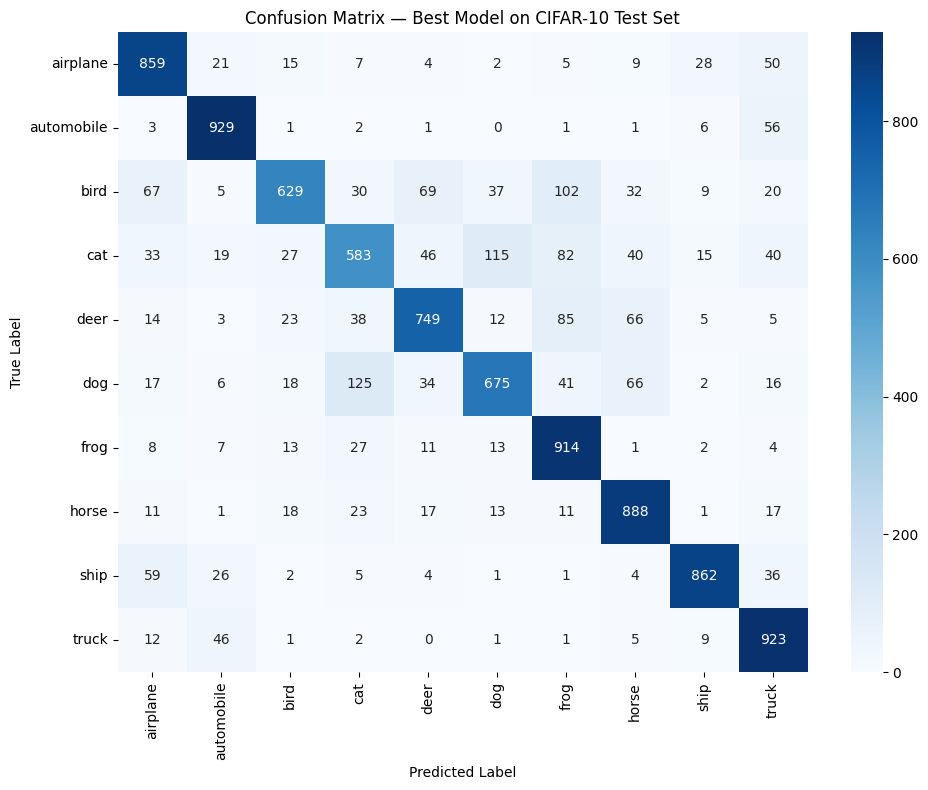


Classification Report:
              precision    recall  f1-score   support

    airplane       0.79      0.86      0.82      1000
  automobile       0.87      0.93      0.90      1000
        bird       0.84      0.63      0.72      1000
         cat       0.69      0.58      0.63      1000
        deer       0.80      0.75      0.77      1000
         dog       0.78      0.68      0.72      1000
        frog       0.74      0.91      0.81      1000
       horse       0.80      0.89      0.84      1000
        ship       0.92      0.86      0.89      1000
       truck       0.79      0.92      0.85      1000

    accuracy                           0.80     10000
   macro avg       0.80      0.80      0.80     10000
weighted avg       0.80      0.80      0.80     10000



In [ ]:
#  Task 5A: Confusion Matrix
# Predict class labels for the entire test set

y_pred_probs = best_model.predict(x_test_standardized)   # shape: (10000, 10)
y_pred       = np.argmax(y_pred_probs, axis=1)            # predicted class index
y_true       = y_test.flatten()                           # true class index

# Build confusion matrix (rows = actual, cols = predicted)
cm = confusion_matrix(y_true, y_pred)

# Plot as heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix — Best Model on CIFAR-10 Test Set')
plt.tight_layout()
plt.show()

# Full classification report (precision, recall, F1 per class)
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

In [ ]:
#Task 5B

misclassified_idx = np.where(y_pred != y_true)[0]
print(f"Total misclassified: {len(misclassified_idx)} / {len(y_test)}")
print(f"Overall accuracy: {(1 - len(misclassified_idx)/len(y_test))*100:.2f}%")

Total misclassified: 1989 / 10000
Overall accuracy: 80.11%


In [ ]:
#  Task 5B  Deliverable 39: 3 Worst-Performing Classes (lowest recall)
# Recall per class = how many true samples of that class were correctly predicted

# Compute per-class recall from the confusion matrix
# recall[i] = cm[i, i] / cm[i, :].sum()  (true positives / all actual positives)
per_class_recall = cm.diagonal() / cm.sum(axis=1)

# Rank classes by recall (ascending = worst first)
worst_class_indices = np.argsort(per_class_recall)[:3]

print("Per-Class Recall:")
for i, recall in enumerate(per_class_recall):
    marker = " ← WORST" if i in worst_class_indices else ""
    print(f"  {CLASS_NAMES[i]:12s}: {recall:.4f}{marker}")

print(f"\n3 Worst Classes: {[CLASS_NAMES[i] for i in worst_class_indices]}")

Per-Class Recall:
  airplane    : 0.8590
  automobile  : 0.9290
  bird        : 0.6290 ← WORST
  cat         : 0.5830 ← WORST
  deer        : 0.7490
  dog         : 0.6750 ← WORST
  frog        : 0.9140
  horse       : 0.8880
  ship        : 0.8620
  truck       : 0.9230

3 Worst Classes: ['cat', 'bird', 'dog']


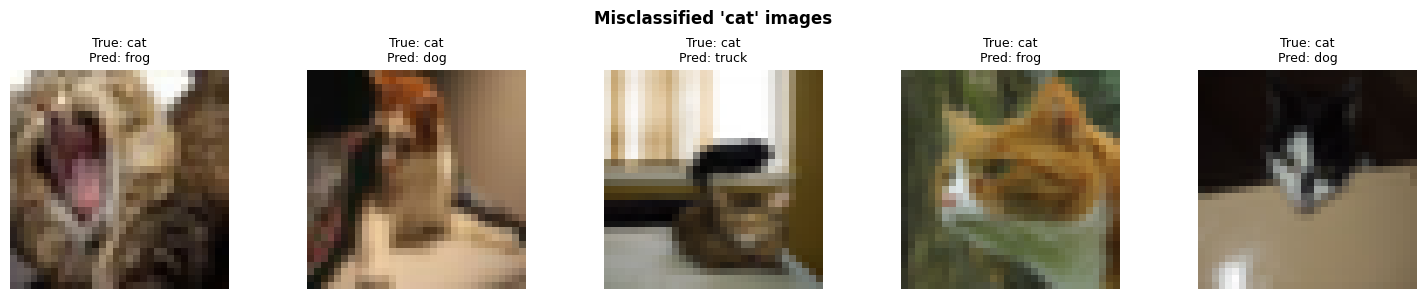

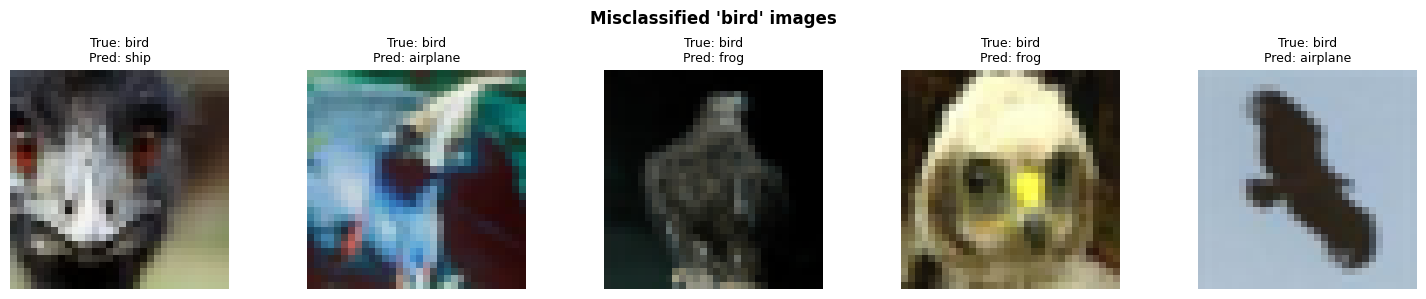

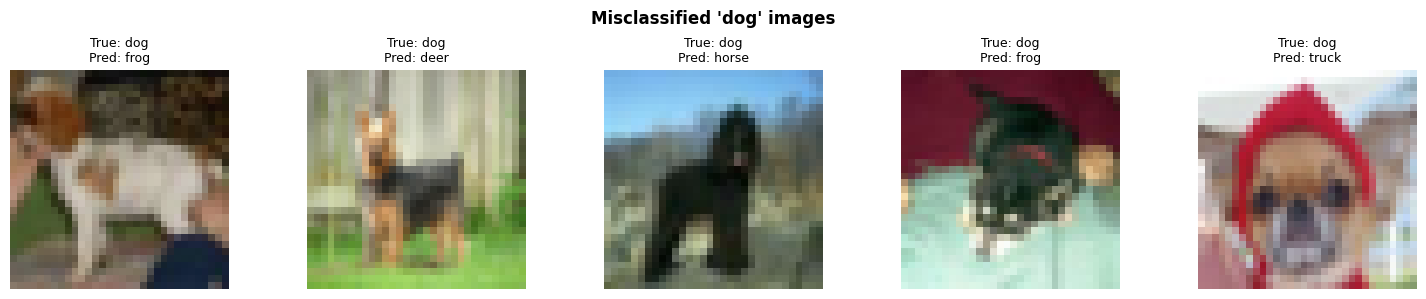

In [ ]:
#  Task 5B  Deliverable 40: Show 5 Misclassified Images per Worst Class

def show_misclassified(true_class_idx, n=5):
    """
    Display n misclassified images for a given true class.
    true_class_idx: integer index (0–9) corresponding to CLASS_NAMES
    """
    # Find test indices where the true label = true_class_idx AND prediction is wrong
    idx = [i for i in misclassified_idx if y_true[i] == true_class_idx][:n]

    if len(idx) == 0:
        print(f"No misclassified samples found for '{CLASS_NAMES[true_class_idx]}'")
        return

    fig, axes = plt.subplots(1, len(idx), figsize=(15, 3))
    for ax, i in zip(axes, idx):
        # x_test holds the raw (un-standardized) pixels for display
        ax.imshow(x_test[i].astype('uint8'))
        ax.set_title(
            f"True: {CLASS_NAMES[y_true[i]]}\nPred: {CLASS_NAMES[y_pred[i]]}",
            fontsize=9
        )
        ax.axis('off')

    plt.suptitle(
        f"Misclassified '{CLASS_NAMES[true_class_idx]}' images",
        fontsize=12, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()


# Show 5 misclassified images for each of the 3 worst classes
for class_idx in worst_class_indices:
    show_misclassified(class_idx, n=5)

In [ ]:
#  Task 5B  Deliverable 41: Top 3 Most Confused Class Pairs
# A confusion pair (A → B) means: model predicted B when true label was A
# We look at off-diagonal entries of the confusion matrix

# Set diagonal to 0 so we only see errors
cm_errors = cm.copy()
np.fill_diagonal(cm_errors, 0)

# Flatten and find top 3 off-diagonal entries
flat_indices = np.argsort(cm_errors.flatten())[::-1][:3]
top_confused_pairs = [(idx // 10, idx % 10) for idx in flat_indices]

print("Top 3 Most Confused Class Pairs (True → Predicted):")
for true_c, pred_c in top_confused_pairs:
    count = cm_errors[true_c, pred_c]
    print(f"  {CLASS_NAMES[true_c]:12s} → {CLASS_NAMES[pred_c]:12s}  ({count} times)")

Top 3 Most Confused Class Pairs (True → Predicted):
  dog          → cat           (125 times)
  cat          → dog           (115 times)
  bird         → frog          (102 times)


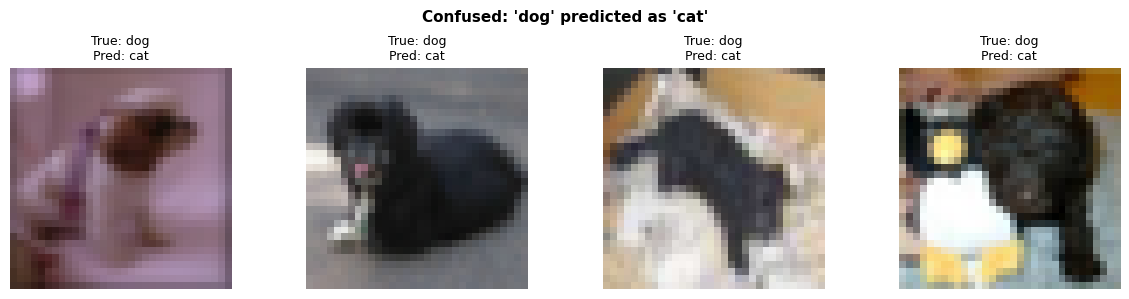

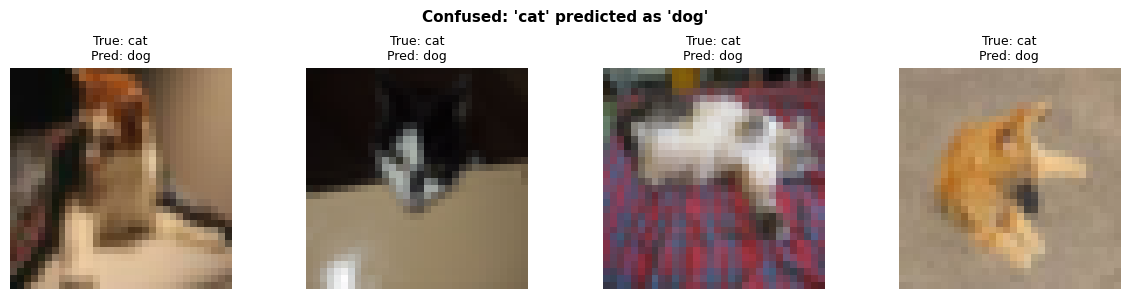

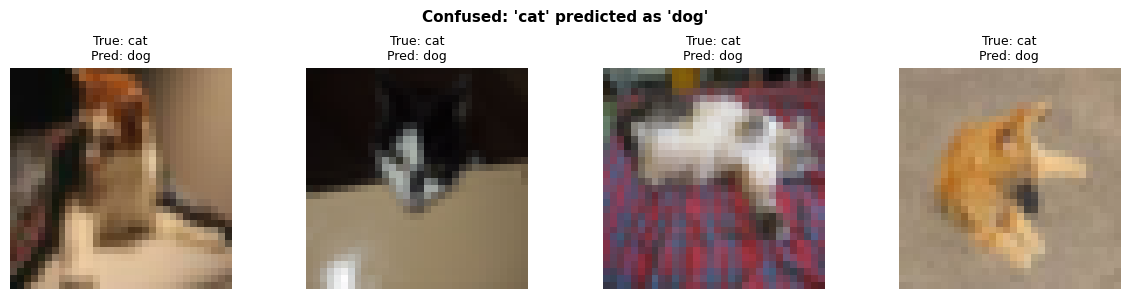

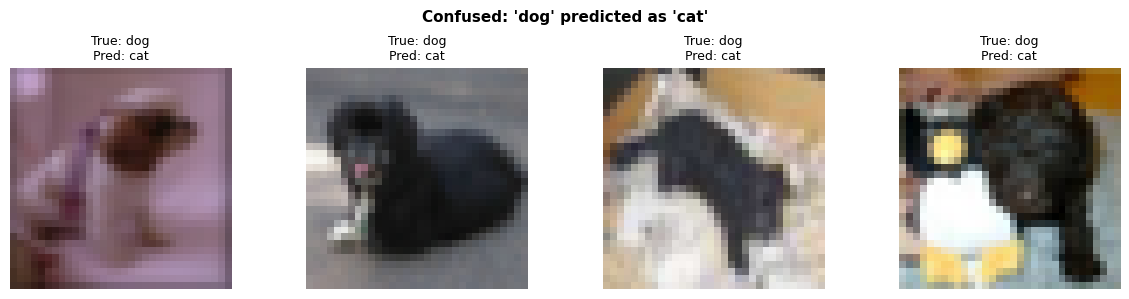

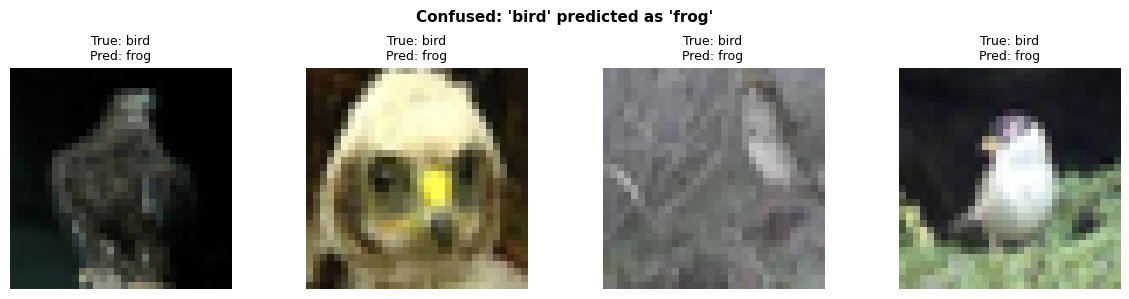

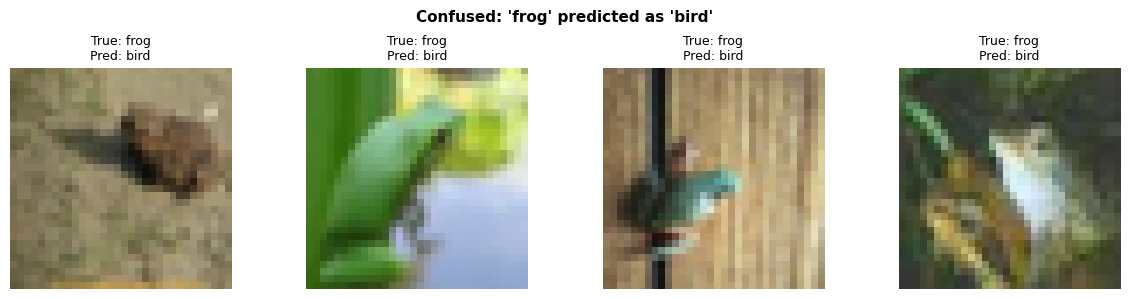

In [ ]:
# ─ Task 5B  Deliverable 41 (cont.): Show 4 Examples per Confusion Direction
# For each confused pair (A, B), show: A predicted as B, AND B predicted as A

def show_confused_pair(true_c, pred_c, n=4):
    """
    Display n examples where true_c was predicted as pred_c.
    """
    idx = [
        i for i in misclassified_idx
        if y_true[i] == true_c and y_pred[i] == pred_c
    ][:n]

    if len(idx) == 0:
        print(f"No samples: {CLASS_NAMES[true_c]} → {CLASS_NAMES[pred_c]}")
        return

    fig, axes = plt.subplots(1, len(idx), figsize=(12, 3))
    # Handle edge case where only 1 sample found
    if len(idx) == 1:
        axes = [axes]
    for ax, i in zip(axes, idx):
        ax.imshow(x_test[i].astype('uint8'))
        ax.set_title(
            f"True: {CLASS_NAMES[true_c]}\nPred: {CLASS_NAMES[pred_c]}",
            fontsize=9
        )
        ax.axis('off')
    plt.suptitle(
        f"Confused: '{CLASS_NAMES[true_c]}' predicted as '{CLASS_NAMES[pred_c]}'",
        fontsize=11, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()


# For each top confused pair, show BOTH directions
for true_c, pred_c in top_confused_pairs:
    show_confused_pair(true_c, pred_c, n=4)   # Direction A → B
    show_confused_pair(pred_c, true_c, n=4)   # Direction B → A

In [ ]:
#  Task 6A: Step 1 — Resize CIFAR-10 Images to 48×48 for VGG16
# VGG16 expects at minimum 48×48 input; CIFAR-10 is 32×32

print("Resizing images to 48×48 (this may take a moment)...")

x_train_resized = tf.image.resize(x_train_standardized, (48, 48)).numpy()
x_val_resized   = tf.image.resize(x_val_standardized,   (48, 48)).numpy()
x_test_resized  = tf.image.resize(x_test_standardized,  (48, 48)).numpy()

print(f"Resized train shape: {x_train_resized.shape}")
print(f"Resized val   shape: {x_val_resized.shape}")
print(f"Resized test  shape: {x_test_resized.shape}")

Resizing images to 48×48 (this may take a moment)...
Resized train shape: (40000, 48, 48, 3)
Resized val   shape: (10000, 48, 48, 3)
Resized test  shape: (10000, 48, 48, 3)


In [ ]:
#  Task 6A  Model 1: From Scratch (Medium CNN, input 48×48)
# Same architecture as Task 2A Medium model, but with larger input shape

def build_medium_cnn(input_shape=(48, 48, 3)):
    """Medium CNN from Task 2A — filters: 32, 32, 64, 64."""
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(10,  activation='softmax')
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


print("=" * 60)
print("Model 1: From Scratch")
print("=" * 60)
model_scratch = build_medium_cnn(input_shape=(48, 48, 3))
model_scratch.summary()

history_scratch, acc_scratch, loss_scratch, time_scratch = train_and_evaluate(
    model_scratch,
    x_train_resized, y_train,
    x_val_resized,   y_val,
    x_test_resized,  y_test,
    epochs=20, batch_size=128
)

Model 1: From Scratch


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 48, 48, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,427,690 (9.26 MB)

 Trainable params: 2,427,690 (9.26 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 39ms/step - accuracy: 0.5054 - loss: 1.3900 - val_accuracy: 0.6141 - val_loss: 1.0906
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.6739 - loss: 0.9329 - val_accuracy: 0.6714 - val_loss: 0.9527
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.7496 - loss: 0.7170 - val_accuracy: 0.6873 - val_loss: 0.9277
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.8119 - loss: 0.5449 - val_accuracy: 0.6847 - val_loss: 1.0266
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.8493 - loss: 0.4322 - val_accuracy: 0.6548 - val_loss: 1.1595
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.8884 - loss: 0.3185 - val_accuracy: 0.6590 - val_loss: 1.2876
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.9222 - loss: 0.2225 - val_accuracy: 0.6643 - val_loss: 1.4965
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.9451 - loss: 0.1580 - val_acc

In [ ]:
#  Task 6A — Model 2: Feature Extraction (Frozen VGG16)
# Load VGG16 pre-trained on ImageNet, freeze ALL layers, add custom head

def build_feature_extraction_model(input_shape=(48, 48, 3)):
    """
    Feature Extraction: VGG16 base (fully frozen) + custom classification head.
    The VGG16 base acts as a fixed feature extractor — its weights never change.
    """
    # Load VGG16 without top classification layers (include_top=False)
    vgg_base = keras.applications.VGG16(
        weights='imagenet',      # load ImageNet pre-trained weights
        include_top=False,       # exclude the final Dense layers
        input_shape=input_shape
    )

    # Freeze ALL VGG16 layers — weights will NOT update during training
    vgg_base.trainable = False

    # Build the full model: frozen VGG16 + custom head
    model = models.Sequential([
        vgg_base,
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


print("=" * 60)
print("Model 2: Feature Extraction (Frozen VGG16)")
print("=" * 60)
model_fe = build_feature_extraction_model()
model_fe.summary()   # Note: trainable vs non-trainable params

history_fe, acc_fe, loss_fe, time_fe = train_and_evaluate(
    model_fe,
    x_train_resized, y_train,
    x_val_resized,   y_val,
    x_test_resized,  y_test,
    epochs=20, batch_size=128
)

Model 2: Feature Extraction (Frozen VGG16)
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 33s 84ms/step - accuracy: 0.5319 - loss: 1.3462 - val_accuracy: 0.6415 - val_loss: 1.0395
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 60ms/step - accuracy: 0.6340 - loss: 1.0603 - val_accuracy: 0.6656 - val_loss: 0.9649
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 58ms/step - accuracy: 0.6588 - loss: 0.9876 - val_accuracy: 0.6770 - val_loss: 0.9350
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 60ms/step - accuracy: 0.6744 - loss: 0.9395 - val_accuracy: 0.6816 - val_loss: 0.9215
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 61ms/step - accuracy: 0.6849 - loss: 0.9039 - val_accuracy: 0.6906 - val_loss: 0.9015
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 65ms/step - accuracy: 0.6962 - loss: 0.8769 - val_accuracy: 0.6915 - val_loss: 0.8947
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 59ms/step - accuracy: 0.7054 - loss: 0.8484 - val_accuracy: 0.6964 - val_loss: 0.8891
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 60ms/step - accuracy: 0.7139 - loss: 0.8269 - 

In [ ]:
# *- Task 6A — Model 3: Fine-Tuning (Unfreeze last 4 VGG16 layers, lr=1e-5)
# Using a very low LR to avoid destroying pre-trained ImageNet weights

def build_finetune_model(learning_rate=1e-5, input_shape=(48, 48, 3)):
    """
    Fine-Tuning: VGG16 base with last 4 layers unfrozen.
    The last 4 VGG16 layers are allowed to adapt to CIFAR-10.
    Low LR (1e-5) prevents catastrophic forgetting of ImageNet features.
    """
    vgg_base = keras.applications.VGG16(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )

    # First, freeze ALL VGG16 layers
    vgg_base.trainable = False

    # Then, unfreeze ONLY the last 4 layers
    for layer in vgg_base.layers[-4:]:
        layer.trainable = True

    # Verify which layers are trainable
    print("VGG16 layer trainability (last 6 layers):")
    for layer in vgg_base.layers[-6:]:
        print(f"  {layer.name:20s} trainable={layer.trainable}")

    # Same classification head as Model 2
    model = models.Sequential([
        vgg_base,
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


print("=" * 60)
print("Model 3: Fine-Tuning (lr=1e-5)")
print("=" * 60)
model_ft_low = build_finetune_model(learning_rate=1e-5)
model_ft_low.summary()   # Note trainable vs non-trainable params

history_ft_low, acc_ft_low, loss_ft_low, time_ft_low = train_and_evaluate(
    model_ft_low,
    x_train_resized, y_train,
    x_val_resized,   y_val,
    x_test_resized,  y_test,
    epochs=20, batch_size=128
)

Model 3: Fine-Tuning (lr=1e-5)
VGG16 layer trainability (last 6 layers):
  block4_conv3         trainable=False
  block4_pool          trainable=False
  block5_conv1         trainable=True
  block5_conv2         trainable=True
  block5_conv3         trainable=True
  block5_pool          trainable=True


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 7,213,322 (27.52 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 34s 88ms/step - accuracy: 0.4163 - loss: 1.6464 - val_accuracy: 0.6767 - val_loss: 0.9635
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 71ms/step - accuracy: 0.6526 - loss: 1.0103 - val_accuracy: 0.7345 - val_loss: 0.7837
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 69ms/step - accuracy: 0.7111 - loss: 0.8461 - val_accuracy: 0.7589 - val_loss: 0.7069
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 69ms/step - accuracy: 0.7445 - loss: 0.7504 - val_accuracy: 0.7729 - val_loss: 0.6590
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 70ms/step - accuracy: 0.7692 - loss: 0.6790 - val_accuracy: 0.7865 - val_loss: 0.6229
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 70ms/step - accuracy: 0.7858 - loss: 0.6305 - val_accuracy: 0.7932 - val_loss: 0.5996
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 70ms/step - accuracy: 0.8034 - loss: 0.5774 - val_accuracy: 0.7996 - val_loss: 0.5794
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 69ms/step - accuracy: 0.8179 - loss: 0.5402 - 

In [ ]:
#  Task 6A — Model 4: Fine-Tuning (Higher LR = 0.001)
# Same architecture as Model 3 (last 4 unfrozen) but with lr=0.001
# This tests whether a high LR destroys the pre-trained weights

print("=" * 60)
print("Model 4: Fine-Tuning (lr=0.001) — High LR Test")
print("=" * 60)
model_ft_high = build_finetune_model(learning_rate=0.001)
# No need to print summary again — same architecture as Model 3

history_ft_high, acc_ft_high, loss_ft_high, time_ft_high = train_and_evaluate(
    model_ft_high,
    x_train_resized, y_train,
    x_val_resized,   y_val,
    x_test_resized,  y_test,
    epochs=20, batch_size=128
)

Model 4: Fine-Tuning (lr=0.001) — High LR Test
VGG16 layer trainability (last 6 layers):
  block4_conv3         trainable=False
  block4_pool          trainable=False
  block5_conv1         trainable=True
  block5_conv2         trainable=True
  block5_conv3         trainable=True
  block5_pool          trainable=True
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 29s 81ms/step - accuracy: 0.0990 - loss: 2.3086 - val_accuracy: 0.0977 - val_loss: 2.3027
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 71ms/step - accuracy: 0.1000 - loss: 2.3027 - val_accuracy: 0.0952 - val_loss: 2.3027
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 68ms/step - accuracy: 0.0995 - loss: 2.3028 - val_accuracy: 0.0952 - val_loss: 2.3027
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 68ms/step - accuracy: 0.0972 - loss: 2.3027 - val_accuracy: 0.0952 - val_loss: 2.3027
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 69ms/step - accuracy: 0.0996 - loss: 2.3027 - val_accuracy: 0.0952 - val_loss: 2.3027
Epoch 6/20
313/313 ━━━━━━━━━━━━

In [ ]:
#  Task 6A — Deliverable 44: Trainable vs Non-Trainable Params Summary

def count_params(model):
    """Return (trainable_params, non_trainable_params) for a model."""
    trainable     = sum(np.prod(v.shape) for v in model.trainable_weights)
    non_trainable = sum(np.prod(v.shape) for v in model.non_trainable_weights)
    return int(trainable), int(non_trainable)


# Collect results for the summary table
results = [
    ("From Scratch",         model_scratch, 0,            acc_scratch,  time_scratch),
    ("Feature Extraction",   model_fe,      0,            acc_fe,       time_fe),
    ("Fine-Tune (lr=1e-5)",  model_ft_low,  0,            acc_ft_low,   time_ft_low),
    ("Fine-Tune (lr=1e-3)",  model_ft_high, 0,            acc_ft_high,  time_ft_high),
]

print(f"{'Model':<25} {'Trainable':>12} {'Non-Trainable':>15} {'Test Acc':>10} {'Time (s)':>10}")
print("-" * 75)
for name, model, _, acc, t in results:
    tr, non_tr = count_params(model)
    print(f"{name:<25} {tr:>12,} {non_tr:>15,} {acc:>10.4f} {t:>10.1f}")

Model                        Trainable   Non-Trainable   Test Acc   Time (s)
---------------------------------------------------------------------------
From Scratch                 2,427,690               0     0.6706      151.5
Feature Extraction             133,898      14,714,688     0.6913      393.6
Fine-Tune (lr=1e-5)          7,213,322       7,635,264     0.8226      450.8
Fine-Tune (lr=1e-3)          7,213,322       7,635,264     0.1000      440.8


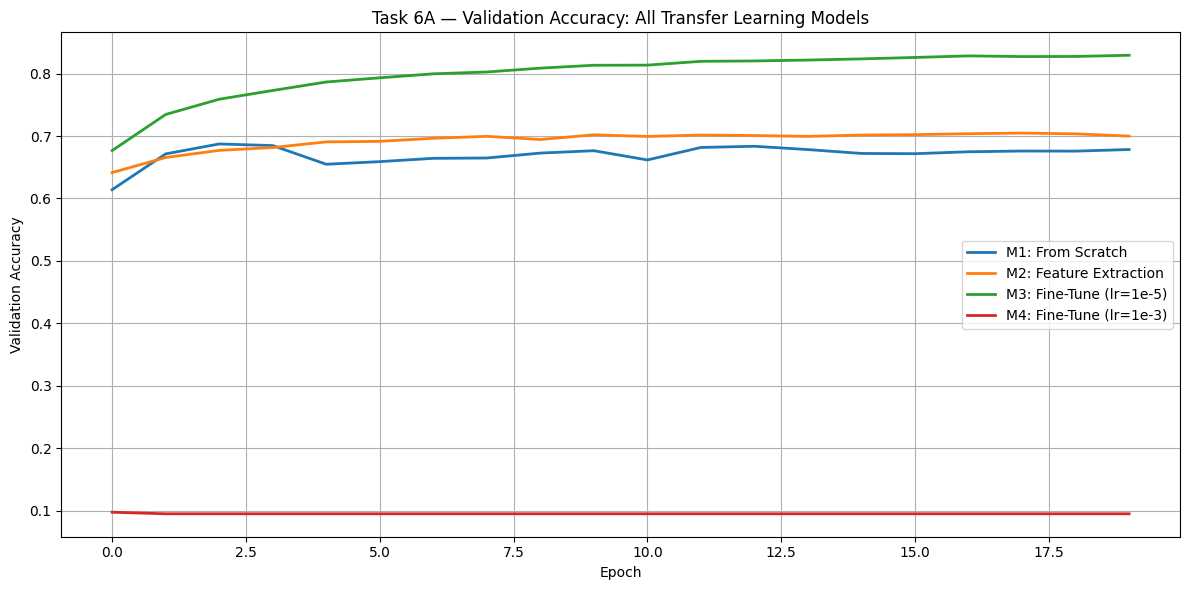

In [ ]:
#  Task 6A — Deliverable 46: Validation Accuracy Curves — All 4 Models

plt.figure(figsize=(12, 6))
plt.plot(history_scratch.history['val_accuracy'],  label='M1: From Scratch',        linewidth=2)
plt.plot(history_fe.history['val_accuracy'],       label='M2: Feature Extraction',  linewidth=2)
plt.plot(history_ft_low.history['val_accuracy'],   label='M3: Fine-Tune (lr=1e-5)', linewidth=2)
plt.plot(history_ft_high.history['val_accuracy'],  label='M4: Fine-Tune (lr=1e-3)', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Task 6A — Validation Accuracy: All Transfer Learning Models')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

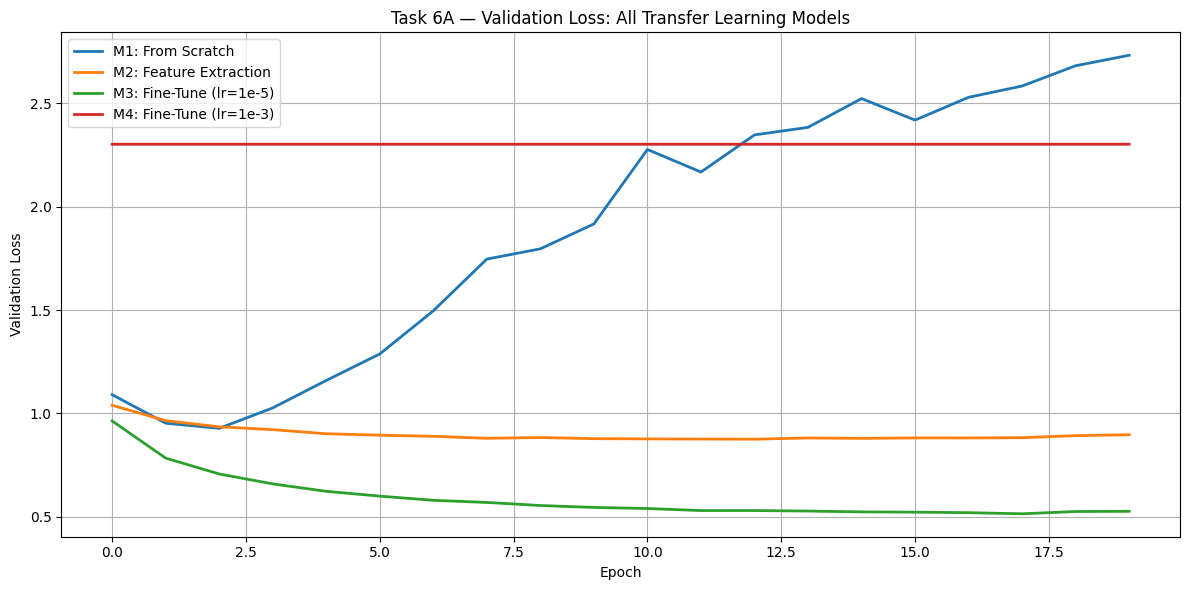

In [ ]:
#  Task 6A — Deliverable 47: Validation Loss Curves — All 4 Models

plt.figure(figsize=(12, 6))
plt.plot(history_scratch.history['val_loss'],  label='M1: From Scratch',        linewidth=2)
plt.plot(history_fe.history['val_loss'],       label='M2: Feature Extraction',  linewidth=2)
plt.plot(history_ft_low.history['val_loss'],   label='M3: Fine-Tune (lr=1e-5)', linewidth=2)
plt.plot(history_ft_high.history['val_loss'],  label='M4: Fine-Tune (lr=1e-3)', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Task 6A — Validation Loss: All Transfer Learning Models')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()